In [1]:
import pandas as pd
from dotenv import load_dotenv
import os 

In [2]:
import sys
sys.path.append("..")

In [3]:
from utils.get_market_data import get_candles

In [4]:
from datetime import datetime, timedelta, timezone
now = datetime.now()
from_ = now - timedelta(days=90)
sber_price = get_candles("SBER", from_, now, interval=1)
sber_price.head()

Number of deleted duplicates: 0


,open,close,high,low,value,volume,end
timestamp,,,,,,,
2026-02-21 11:54:00,313.56,313.57,313.57,313.55,50483.64,161,2026-02-21 11:54:59
2026-02-21 11:55:00,313.57,313.56,313.57,313.56,62712.17,200,2026-02-21 11:55:59
2026-02-21 11:56:00,313.57,313.57,313.57,313.55,112254.0,358,2026-02-21 11:56:59
2026-02-21 11:57:00,313.55,313.55,313.57,313.55,58949.9,188,2026-02-21 11:57:59
2026-02-21 11:58:00,313.57,313.57,313.57,313.55,45466.87,145,2026-02-21 11:58:59


In [5]:
load_dotenv()
db_url = os.getenv("DB_URL")

In [6]:
import psycopg2

conn = psycopg2.connect(db_url)
cur = conn.cursor()

ticker = "SR320CD6A"
strike = 320
expiry_date = datetime(2026, 4, 1, 19, tzinfo=timezone.utc)

cur.execute("""
SELECT timestamp, bids, asks FROM orderbooks
WHERE ticker = %s
""", (ticker,))

rows = cur.fetchall()

In [136]:
df = pd.DataFrame(rows, columns=['timestamp', 'bids', 'asks'])
df.head(1)

,timestamp,bids,asks
0,2026-03-23 16:00:48+00:00,"[{'price': 2.2, 'quantity': 1}, {'price': 1.89...","[{'price': 2.99, 'quantity': 447}, {'price': 3..."


In [137]:
df['best_bid'] = df['bids'].apply(lambda x: x[0]['price'] if x else None)
df['best_ask'] = df['asks'].apply(lambda x: x[0]['price'] if x else None)

df['mid'] = ((df['best_ask'] + df['best_bid']) / 2)#.fillna(df['best_ask']).fillna(df['best_bid'])
df = df[['timestamp', 'best_bid', 'best_ask', 'mid']]

In [138]:
df['time_to_expiry'] = df['timestamp'].apply(lambda x: (expiry_date - x).total_seconds()/31536000)
df.head(1)

,timestamp,best_bid,best_ask,mid,time_to_expiry
0,2026-03-23 16:00:48+00:00,2.2,2.99,2.595,0.024998


In [139]:
sber_price_df = sber_price[['close']]
sber_price_df.head(5)

,close
timestamp,
2026-02-21 11:54:00,313.57
2026-02-21 11:55:00,313.56
2026-02-21 11:56:00,313.57
2026-02-21 11:57:00,313.55
2026-02-21 11:58:00,313.57


In [140]:
sber_price_df['merge_time'] = sber_price_df.index
sber_price_df['merge_time'] = sber_price_df['merge_time'].dt.tz_localize('UTC')
sber_price_df = sber_price_df.sort_values('merge_time')
df = df.sort_values('timestamp')


merged_df = pd.merge_asof(
    df,
    sber_price_df,
    left_on = "timestamp",
    right_on = "merge_time"
)

merged_df.dropna(inplace=True)
merged_df.head()

,timestamp,best_bid,best_ask,mid,time_to_expiry,close,merge_time
0,2026-03-23 15:50:01+00:00,2.20,2.99,2.595,0.025019,317.09,2026-03-23 15:50:00+00:00
1,2026-03-23 15:50:01+00:00,2.20,2.99,2.595,0.025019,317.09,2026-03-23 15:50:00+00:00
2,2026-03-23 15:50:01+00:00,2.20,2.99,2.595,0.025019,317.09,2026-03-23 15:50:00+00:00
3,2026-03-23 16:00:48+00:00,2.20,2.99,2.595,0.024998,317.1,2026-03-23 16:00:00+00:00
4,2026-03-23 16:05:42+00:00,1.89,2.99,2.440,0.024989,317.01,2026-03-23 16:05:00+00:00


In [141]:
from utils.iv_solver import iv_newton, price
def price_bs(row):
    try:
        return price(
            row.close,
            strike,
            0.13,
            0.2,
            row.time_to_expiry,
            "CALL"
        )
    except Exception as e:
        print(e)
        return None


def exception_iv(row, option_price):
    try:
        return iv_newton(
            row.close, 
            strike, 
            0.13, 
            row.time_to_expiry, 
            option_price, 
            "CALL",
            0.0001 , 
            100
        )
    except ValueError as e:
        print(e)
        return None
        

merged_df['IV_mid'] = merged_df.apply(lambda row: exception_iv(row, row.mid), axis=1)
merged_df['IV_ask'] = merged_df.apply(lambda row: exception_iv(row, row.best_ask), axis=1)
merged_df['IV_bid'] = merged_df.apply(lambda row: exception_iv(row, row.best_bid), axis=1)
merged_df['bs_price'] = merged_df.apply(lambda row: price_bs(row), axis=1)
merged_df.head(1)

,timestamp,best_bid,best_ask,mid,time_to_expiry,close,merge_time,IV_mid,IV_ask,IV_bid,bs_price
0,2026-03-23 15:50:01+00:00,2.2,2.99,2.595,0.025019,317.09,2026-03-23 15:50:00+00:00,0.171922,0.192023,0.151708,3.147199


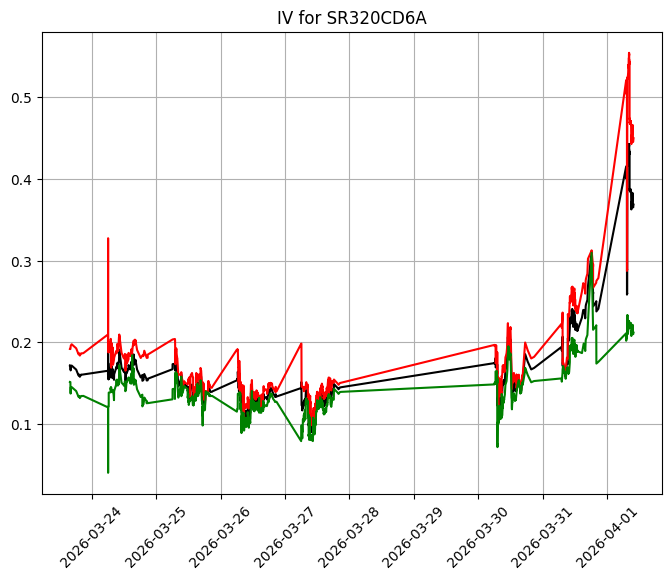

In [146]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(8,6))

plt.plot(merged_df['timestamp'], merged_df['IV_mid'], color="black")
plt.plot(merged_df['timestamp'], merged_df['IV_ask'],color="red")
plt.plot(merged_df['timestamp'], merged_df['IV_bid'], color="green")
plt.title(f"IV for {ticker}")
plt.xticks(rotation=45) 
#|plt.ylim(0, 1)
plt.grid()

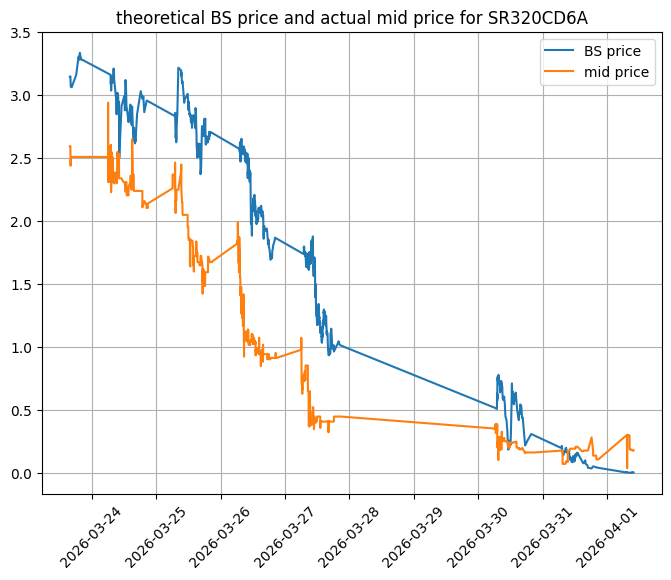

In [147]:
fig = plt.figure(figsize=(8,6))

plt.plot(merged_df['timestamp'], merged_df['bs_price'], label="BS price")
plt.plot(merged_df['timestamp'], merged_df['mid'], label="mid price")
plt.legend()
plt.title(f"theoretical BS price and actual mid price for {ticker}")
plt.xticks(rotation=45) 
plt.grid()